In [ ]:
import os
import librosa as lr
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd

# CNN MFFC on GTZAN Dataset

## Utility Functions

In [17]:
FMA_FOLDER_PATH = "data/fma_small/"
GTZAN_FOLDER_PATH = "data/gtzan/genres/"
def fma_row_to_file_path(row):
    track_id = row["track_id"]
    return os.path.join(FMA_FOLDER_PATH, f"{track_id//1000:03d}", f"{track_id:06d}.mp3")

def gtzan_row_to_file_path(row):
    genre = row["genre_name"]
    track_id = row["track_id"]
    return os.path.join(GTZAN_FOLDER_PATH, genre, f"{genre}.{track_id:05d}.au")

In [18]:
def load_gtzan_mfcc_data(gtzan_tracks, chunk_duration=3.0, audio_duration=30.0, n_fft=2048, hop_length=512, sr=22050, n_mfcc=20):
    num_samples = int(audio_duration * sr)
    chunk_samples = int(chunk_duration * sr)
    
    # Calculate exact chunks (e.g., 30s / 3s = 10 chunks)
    num_chunks = int(num_samples // chunk_samples) 
    
    # Librosa centers frames by default, so output frames is just samples // hop_length + 1
    windows_per_chunk = (chunk_samples // hop_length) + 1 
    
    set_size = len(gtzan_tracks)
    total_items = set_size * num_chunks

    # Pre-allocate 
    X = np.zeros((total_items, 3 * n_mfcc, windows_per_chunk), dtype=np.float32)
    y = np.zeros((total_items,), dtype=np.int32) # 1D array for labels

    # Use enumerate to get a safe, sequential write index
    for track_idx, (index, row) in enumerate(gtzan_tracks.iterrows()):
        # Assuming gtzan_row_to_file_path is defined in your environment
        audio_path = gtzan_row_to_file_path(row) 
        audio_data, _ = lr.load(audio_path, sr=sr, duration=audio_duration)
        
        # Ensure consistent length for the 30s track
        if len(audio_data) < num_samples:
            audio_data = np.pad(audio_data, (0, num_samples - len(audio_data)))
        else:
            audio_data = audio_data[:num_samples]

        # Extract 3-second chunks
        for i in range(num_chunks):
            write_pos = (track_idx * num_chunks) + i
            
            chunk_start = i * chunk_samples
            chunk_end = chunk_start + chunk_samples
            chunk = audio_data[chunk_start:chunk_end] 
            
            # Compute MFCC for the entire 3-second chunk at once
            mfcc = lr.feature.mfcc(y=chunk, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
            mfcc_delta = lr.feature.delta(mfcc)
            # Compute second derivative (delta-delta)
            mfcc_delta2 = lr.feature.delta(mfcc, order=2)
            # Stack them
            combined_features = np.vstack([mfcc, mfcc_delta, mfcc_delta2])
            # Safety block: Ensure exact dimension match in case of float rounding drift
            if mfcc.shape[1] > windows_per_chunk:
                mfcc = mfcc[:, :windows_per_chunk]
            elif mfcc.shape[1] < windows_per_chunk:
                mfcc = np.pad(mfcc, ((0, 0), (0, windows_per_chunk - mfcc.shape[1])))
            
            X[write_pos] = combined_features
            y[write_pos] = row["genre_id"]
            
    return X, y

## Load the Dataset

In [19]:
gtzan_tracks = pd.read_csv("data/gtzan_tracks.csv")
dataset, labels = load_gtzan_mfcc_data(gtzan_tracks)
dataset = np.array(dataset, dtype=np.float32)
labels = np.array(labels)
print(dataset.shape, labels.shape)

/home/rosgeek/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(10000, 60, 130) (10000,)


In [20]:
labels = tf.keras.utils.to_categorical(labels, num_classes=10)
labels.shape

(10000, 10)

In [21]:
dataset_min, dataset_max = dataset.min(), dataset.max()
dataset = (dataset - dataset_min) / (dataset_max - dataset_min)

In [22]:
X = dataset[:, :, :]
X.shape

(10000, 60, 130)

In [23]:
X = np.transpose(X, (0,2,1))

In [24]:
X.shape

(10000, 130, 60)

## Shuffle Dataset

In [25]:
from sklearn.utils import shuffle
X_train, Y_train = shuffle(X, labels, random_state=42)

In [26]:
X_train.shape

(10000, 130, 60)

## Build Model

In [60]:
from tensorflow.keras import regularizers
def build_regularized_model(input_shape=(130, 60)): # Assuming the 1D route
    model = tf.keras.Sequential()

    # 1st block: Reduced filters
    model.add(tf.keras.layers.Conv1D(16, 3, padding="same", activation='relu', input_shape=input_shape))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))

    # 2nd block
    model.add(tf.keras.layers.Conv1D(16, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))

    # 3rd block
    model.add(tf.keras.layers.Conv1D(32, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.Conv1D(32, 3, activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))
    model.add(tf.keras.layers.Dropout(0.2)) # Heavier dropout deeper in the network

    model.add(tf.keras.layers.Conv1D(64, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))
    model.add(tf.keras.layers.Conv1D(64, 3,  padding="same", activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2))
    model.add(tf.keras.layers.Dropout(0.2)) # Heavier dropout deeper in the network

    # Dense head with L2 Regularization
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(tf.keras.layers.Dropout(0.2))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

In [65]:
model = build_regularized_model()
model.summary()

/home/rosgeek/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 130, 16)        │         2,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 130, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 65, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 65, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 65, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 33, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 33, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 31, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 16, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 8, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,138 (172.41 KB)

 Trainable params: 44,074 (172.16 KB)

 Non-trainable params: 64 (256.00 B)

## Compile & Train the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy()
    ]
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   # Cut the learning rate in half
    patience=10,  # If val_loss doesn't improve for 10 epochs
    min_lr=1e-5   # Don't let the learning rate go to absolute zero
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'cnn_mfcc_gtzan.keras', 
    monitor='val_categorical_accuracy', 
    save_best_only=True, 
    mode='max'
)

import json
history = model.fit(
    X_train, Y_train, batch_size=32, epochs=300, verbose="auto", validation_split=0.3, 
    callbacks=[reduce_lr, checkpoint]
)

## Save the Final Model & Training History

In [ ]:
with open("models/gtzan/cnn_mel_spec/cnn_mel_spec_train_history.json", "w") as f:
    json.dump(history.history, f)
model.save("models/gtzan/cnn_mel_spec/cnn_mel_spec.h5")

Epoch 1/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - categorical_accuracy: 0.1384 - loss: 3.2782 - val_categorical_accuracy: 0.1067 - val_loss: 3.1028 - learning_rate: 1.0000e-04
Epoch 2/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.3086 - loss: 2.6997 - val_categorical_accuracy: 0.1597 - val_loss: 2.9102 - learning_rate: 1.0000e-04
Epoch 3/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.3467 - loss: 2.4310 - val_categorical_accuracy: 0.1453 - val_loss: 2.8782 - learning_rate: 1.0000e-04
Epoch 4/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.3825 - loss: 2.2264 - val_categorical_accuracy: 0.0977 - val_loss: 4.7413 - learning_rate: 1.0000e-04
Epoch 5/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.4107 - loss: 2.0880 - val_categorical_accuracy: 0.1763 - val_loss: 4.6873 - learning_rate: 1.0000e-04
Epoch 6/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.4240 - loss: 1.

## CNN MFCC Model on FMA Data: 8 Classes

## Utility Functions

In [29]:
fma_tracks = pd.read_csv("data/fma_tracks.csv")

In [30]:
def load_fma_mfcc_data(fma_tracks, chunk_duration=3.0, audio_duration=30.0, n_fft=2048, hop_length=512, sr=22050, n_mfcc=13):
    num_samples = int(audio_duration * sr)
    chunk_samples = int(chunk_duration * sr)
    
    # Calculate exact chunks (e.g., 30s / 3s = 10 chunks)
    num_chunks = int(num_samples // chunk_samples) 
    
    # Librosa centers frames by default, so output frames is just samples // hop_length + 1
    windows_per_chunk = (chunk_samples // hop_length) + 1 
    
    set_size = len(fma_tracks)
    total_items = set_size * num_chunks

    # Pre-allocate 
    X = np.zeros((total_items, 3 * n_mfcc, windows_per_chunk), dtype=np.float32)
    y = np.zeros((total_items,), dtype=np.int32) # 1D array for labels

    # Use enumerate to get a safe, sequential write index
    for track_idx, (index, row) in enumerate(fma_tracks.iterrows()):
        # Assuming gtzan_row_to_file_path is defined in your environment
        audio_path = fma_row_to_file_path(row) 
        audio_data, _ = lr.load(audio_path, sr=sr, duration=audio_duration)
        
        # Ensure consistent length for the 30s track
        if len(audio_data) < num_samples:
            audio_data = np.pad(audio_data, (0, num_samples - len(audio_data)))
        else:
            audio_data = audio_data[:num_samples]

        # Extract 3-second chunks
        for i in range(num_chunks):
            write_pos = (track_idx * num_chunks) + i
            
            chunk_start = i * chunk_samples
            chunk_end = chunk_start + chunk_samples
            chunk = audio_data[chunk_start:chunk_end] 
            
            # Compute MFCC for the entire 3-second chunk at once
            mfcc = lr.feature.mfcc(y=chunk, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
            mfcc_delta = lr.feature.delta(mfcc)
            # Compute second derivative (delta-delta)
            mfcc_delta2 = lr.feature.delta(mfcc, order=2)
            # Stack them
            combined_features = np.vstack([mfcc, mfcc_delta, mfcc_delta2])
            # Safety block: Ensure exact dimension match in case of float rounding drift
            if mfcc.shape[1] > windows_per_chunk:
                mfcc = mfcc[:, :windows_per_chunk]
            elif mfcc.shape[1] < windows_per_chunk:
                mfcc = np.pad(mfcc, ((0, 0), (0, windows_per_chunk - mfcc.shape[1])))
            
            X[write_pos] = combined_features
            y[write_pos] = row["genre_top_id"]
            
    return X, y

## Load the Dataset

In [31]:
dataset, labels = load_fma_mfcc_data(fma_tracks)
dataset = np.array(dataset, dtype=np.float32)
labels = np.array(labels)
print(dataset.shape, labels.shape)

[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)


(20000, 39, 130) (20000,)


In [32]:
labels.shape

(20000,)

## Format the Label ID's for One Hot Encoding

In [33]:
label_ids = fma_tracks["genre_top_id"].unique()
label_ids

array([  17,   12,   21,    2,   10,   38,   15, 1235])

In [34]:
tf_labels = labels.copy()
label_mapping = {label_ids[i]: i for i in range(8)}
for genre_id in label_ids:
    tf_labels[tf_labels == genre_id] = label_mapping[genre_id]
tf_labels

array([0, 0, 0, ..., 3, 3, 3], dtype=int32)

In [35]:
tf_labels = tf.keras.utils.to_categorical(tf_labels, num_classes=8)
tf_labels.shape

(20000, 8)

## Standardized Dataset Scaling

In [36]:
dataset_min, dataset_max = dataset.min(), dataset.max()
dataset = (dataset - dataset_min) / (dataset_max - dataset_min)

In [37]:
X = dataset[:, :, :]
X.shape

(20000, 39, 130)

## Input Dimension Manipulation

In [38]:
X = np.transpose(X, (0,2,1))

In [39]:
X.shape

(20000, 130, 39)

## Shuffle the Dataset

In [40]:
from sklearn.utils import shuffle
X_train, Y_train = shuffle(X, tf_labels, random_state=42)

In [41]:
X_train.shape

(20000, 130, 39)

## Build the Model

In [43]:
from tensorflow.keras import regularizers
def build_regularized_fma_model(input_shape=(130, 39)): # Assuming the 1D route
    model = tf.keras.Sequential()

    # 1st block: Reduced filters
    model.add(tf.keras.layers.Conv1D(32, 3, padding="same", activation='relu', input_shape=input_shape))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))

    # 2nd block
    model.add(tf.keras.layers.Conv1D(32, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))
    # 3rd block
    model.add(tf.keras.layers.Conv1D(64, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.Conv1D(64, 3, activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))
    model.add(tf.keras.layers.Dropout(0.2)) # Heavier dropout deeper in the network

    model.add(tf.keras.layers.Conv1D(128, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.Conv1D(128, 3,  padding="same", activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(0.2)) # Heavier dropout deeper in the network


    model.add(tf.keras.layers.Conv1D(256, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.Conv1D(256, 3, padding="same", activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2, padding='same'))
    model.add(tf.keras.layers.Dropout(0.2)) # Heavier dropout deeper in the network

    # Dense head with L2 Regularization
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu',))
    model.add(tf.keras.layers.Dense(8, activation='softmax'))

    return model

In [44]:
model = build_regularized_fma_model()
model.summary()

/home/rosgeek/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 130, 32)        │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 130, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 65, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 65, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 65, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 33, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 33, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 31, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 8, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 8, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461,736 (1.76 MB)

 Trainable params: 461,352 (1.76 MB)

 Non-trainable params: 384 (1.50 KB)

## Compile the Model

In [45]:
#Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy()
    ]
)

## Train & Save the Model

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   # Cut the learning rate in half
    patience=10,  # If val_loss doesn't improve for 10 epochs
    min_lr=1e-5   # Don't let the learning rate go to absolute zero
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'cnn_mfcc_fma.keras', 
    monitor='val_categorical_accuracy', 
    save_best_only=True, 
    mode='max'
)

history = model.fit(
    X_train, Y_train, batch_size=32, epochs=325, verbose="auto", validation_split=0.4, 
    callbacks=[reduce_lr, checkpoint]
)
with open("models/fma/cnn_mfcc/cnn_fma_mfcc_train_history.json","w") as f:
    json.dump(history.history, f)

model.save("models/fma/cnn_mfcc/cnn_mfcc_fma.keras")

Epoch 1/325
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - categorical_accuracy: 0.2808 - loss: 1.8474 - val_categorical_accuracy: 0.1542 - val_loss: 1.9922 - learning_rate: 1.0000e-04
Epoch 2/325
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.3864 - loss: 1.6074 - val_categorical_accuracy: 0.2848 - val_loss: 2.3282 - learning_rate: 1.0000e-04
Epoch 3/325
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.4190 - loss: 1.5354 - val_categorical_accuracy: 0.1544 - val_loss: 2.5606 - learning_rate: 1.0000e-04
Epoch 4/325
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.4347 - loss: 1.5046 - val_categorical_accuracy: 0.1364 - val_loss: 4.2701 - learning_rate: 1.0000e-04
Epoch 5/325
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.4470 - loss: 1.4713 - val_categorical_accuracy: 0.1314 - val_loss: 6.3158 - learning_rate: 1.0000e-04
Epoch 6/325
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.4552 - loss: 1.4

## Model Performance

## Training Performance Graphing Function

In [42]:
import json
import matplotlib.pyplot as plt

def plot_training_history(history_file_path):
    try:
        with open(history_file_path, 'r') as f:
            history = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file at '{history_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file at '{history_file_path}' is not valid JSON.")
        return

    # Handle standard key variations between different TensorFlow versions
    categorical_accuracy = "categorical_accuracy" if "categorical_accuracy" in history else "categorical_acc"
    val_categorical_accuracy = "val_categorical_accuracy" if "val_categorical_accuracy" in history else "val_categorical_acc" 

    # Generate epoch numbers (1 to N)
    epochs = range(1, len(history['loss']) + 1)

    # 2. Set up the plotting canvas (1 row, 2 columns)
    plt.figure(figsize=(14, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], label='Training Loss', color='teal', linewidth=2)
    
    if 'val_loss' in history:
        plt.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
        
    plt.title('Loss Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)

    # --- Plot 2: Accuracy ---
    plt.subplot(1, 2, 2)
    if categorical_accuracy in history:
        plt.plot(epochs, history['categorical_accuracy'], label='Training Accuracy', color='teal', linewidth=2)
    if val_categorical_accuracy in history:
        plt.plot(epochs, history['val_categorical_accuracy'], label='Validation Accuracy', color='orange', linewidth=2, linestyle="--")
        
    plt.title('Accuracy Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.7)

    # 3. Render the graphs
    plt.tight_layout()
    plt.show()

## CNN MFFC on GTZAN Training Performance

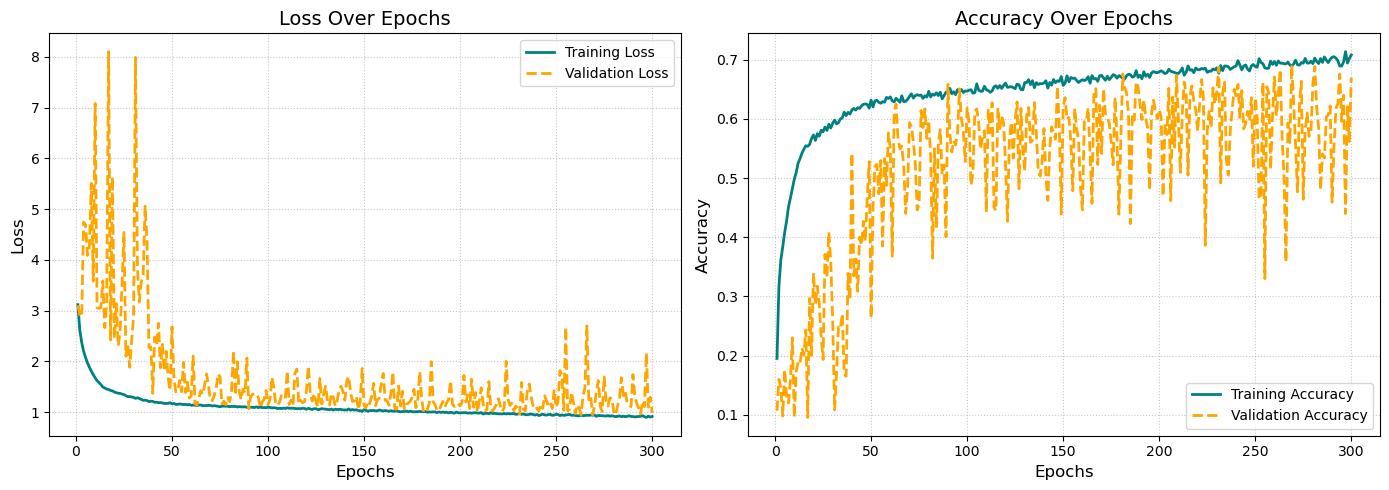

In [43]:
plot_training_history("models/gtzan/cnn_mfcc/cnn_mfcc_gtzan.json")

## CNN MFFC on FMA Training Performance

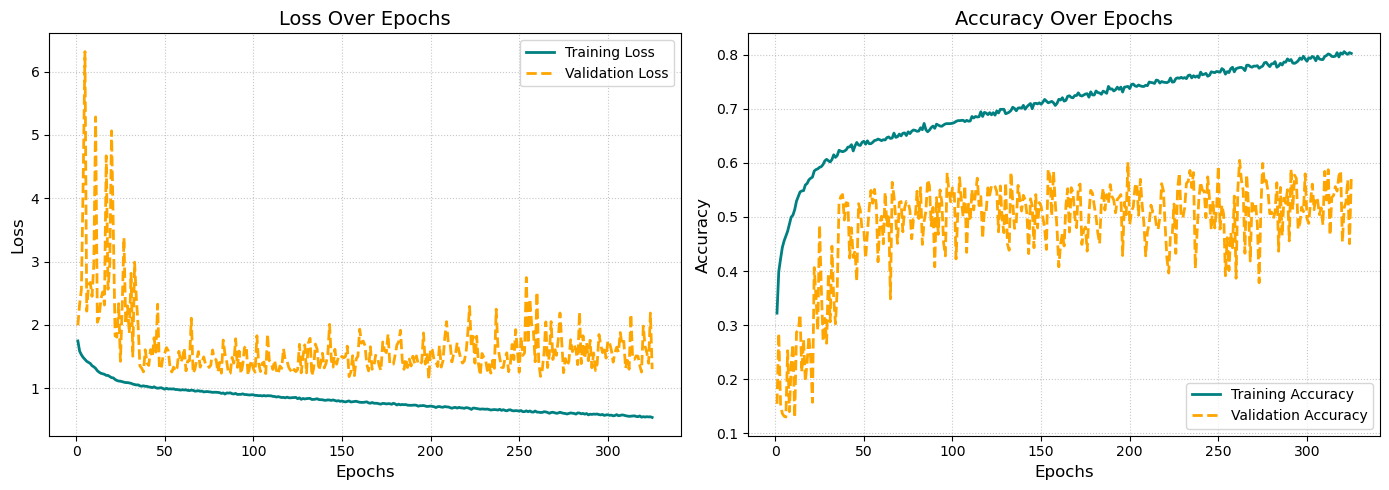

In [44]:
plot_training_history("models/fma/cnn_mfcc/cnn_fma_mfcc_train_history.json")

## Final Comments

- End of the notebook